# Mohammed Sherbini - Extra Trees Multiclass Diabetes Prediction

**Project:** Advanced Ensemble Boosting for Diabetes Prediction  
**Environment:** Google Colab  
**Dataset used:** `diabetes_012_health_indicators_BRFSS2015.csv` only  
**Target:** original `diabetes_012` classes `0`, `1`, and `2`

## What this notebook covers
- Data loading, cleaning, preprocessing, and EDA on the BRFSS dataset.
- A simple Extra Trees training flow using train/test split, SMOTE, and fixed model parameters.
- Feature selection diagnostics using correlation, ANOVA F-test, and mutual information.
- Model evaluation with multiclass accuracy, balanced accuracy, precision, recall, F1, MCC, ROC AUC, and PR AUC.
- Explainability with model importance, SHAP, LIME, permutation importance, drop-column importance, PDP, ICE, ALE, and interaction H-statistics.

In [1]:
!pip -q install xgboost lightgbm shap imbalanced-learn lime

import os
import warnings
warnings.filterwarnings("ignore")

from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from imblearn.over_sampling import SMOTE
from lime.lime_tabular import LimeTabularExplainer
import shap

from sklearn.base import clone
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 1. Data Loading and Cleaning

The loader checks for the dataset in common Colab and repository paths. It standardizes column names, keeps the three-class `diabetes_012` target, removes duplicate rows, and drops weak or negative-impact columns before modeling.

In [2]:
data_paths = [
    "/content/diabetes_012_health_indicators_BRFSS2015.csv",
    "diabetes_012_health_indicators_BRFSS2015.csv",
    "../diabetes_012_health_indicators_BRFSS2015.csv",
]

for data_path in data_paths:
    if os.path.exists(data_path):
        df = pd.read_csv(data_path)
        print("Loaded dataset from:", data_path)
        break
else:
    raise FileNotFoundError("Upload diabetes_012_health_indicators_BRFSS2015.csv to Colab or keep it beside this notebook.")

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("Original shape:", df.shape)
display(df.head())

if "diabetes_012" not in df.columns:
    raise KeyError("This notebook expects the multiclass diabetes_012 target with classes 0, 1, and 2.")

df["diabetes_012"] = df["diabetes_012"].astype(int)

removed_columns = [column for column in [
    "income",
    "fruits",
    "veggies",
    "menthlth",
    "anyhealthcare",
    "nodocbccost",
    "hvyalcoholconsump",
    "physactivity",
    "education",
] if column in df.columns]

df = df.drop(columns=removed_columns)
print("Dropped weak or negative-impact columns:", removed_columns)

print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).rename("missing_values"))

print("Duplicate rows:", int(df.duplicated().sum()))
df = df.drop_duplicates().reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("Target distribution:")
display(df["diabetes_012"].value_counts().sort_index().rename("count"))

print("Target distribution percentage:")
display((df["diabetes_012"].value_counts(normalize=True).sort_index() * 100).round(2).rename("percentage"))

display(df.head())

Loaded dataset from: /content/diabetes_012_health_indicators_BRFSS2015.csv
Original shape: (253680, 22)


,diabetes_012,highbp,highchol,cholcheck,bmi,smoker,stroke,heartdiseaseorattack,physactivity,fruits,...,anyhealthcare,nodocbccost,genhlth,menthlth,physhlth,diffwalk,sex,age,education,income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Dropped weak or negative-impact columns: ['income', 'fruits', 'veggies', 'menthlth', 'anyhealthcare', 'nodocbccost', 'hvyalcoholconsump', 'physactivity', 'education']
Missing values:


,missing_values
diabetes_012,0
highbp,0
highchol,0
cholcheck,0
bmi,0
smoker,0
stroke,0
heartdiseaseorattack,0
genhlth,0
physhlth,0


Duplicate rows: 134525
Cleaned shape: (119155, 13)
Target distribution:


,count
diabetes_012,
0,87090
1,4357
2,27708


Target distribution percentage:


,percentage
diabetes_012,
0,73.09
1,3.66
2,23.25


,diabetes_012,highbp,highchol,cholcheck,bmi,smoker,stroke,heartdiseaseorattack,genhlth,physhlth,diffwalk,sex,age
0,0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,5.0,15.0,1.0,0.0,9.0
1,0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,7.0
2,0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,5.0,30.0,1.0,0.0,9.0
3,0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,11.0
4,0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,11.0


## 2. EDA for Extra Trees Modeling

The EDA focuses on the three target classes, class imbalance, class-2 diabetes rate by important health indicators, class-level summaries, and correlation patterns.

,diabetes_012,count,share
0,0,87090,0.730897
1,1,4357,0.036566
2,2,27708,0.232537


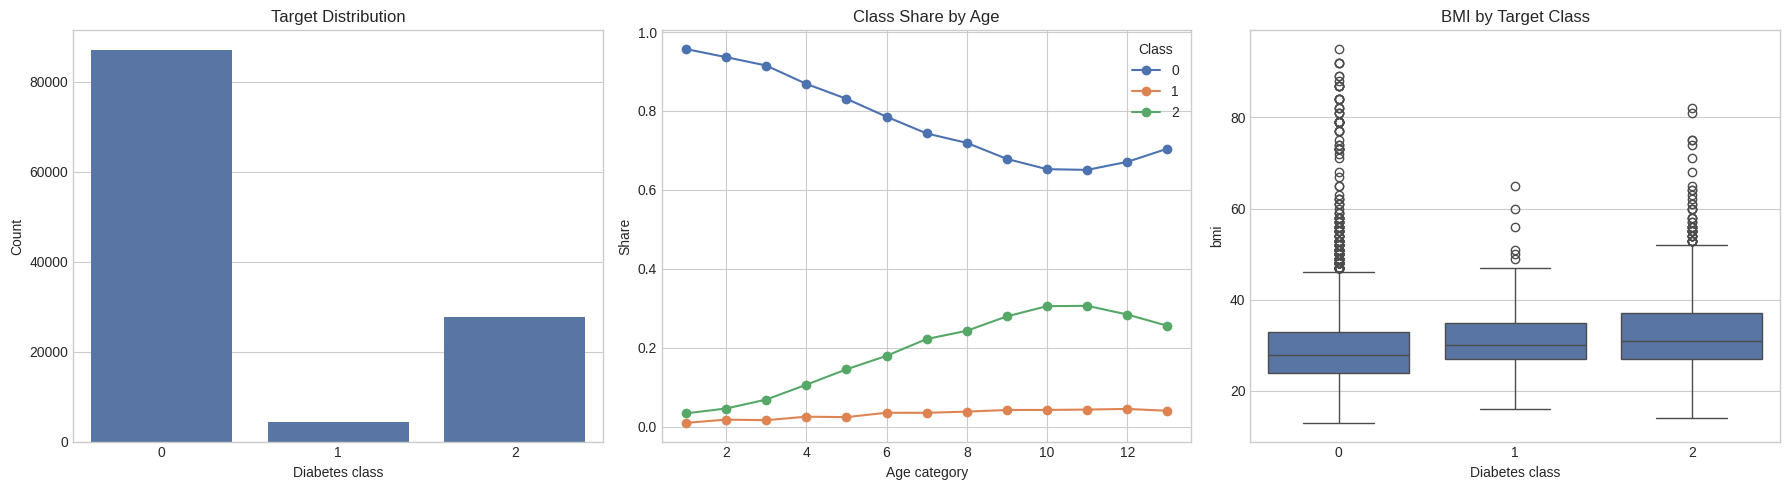

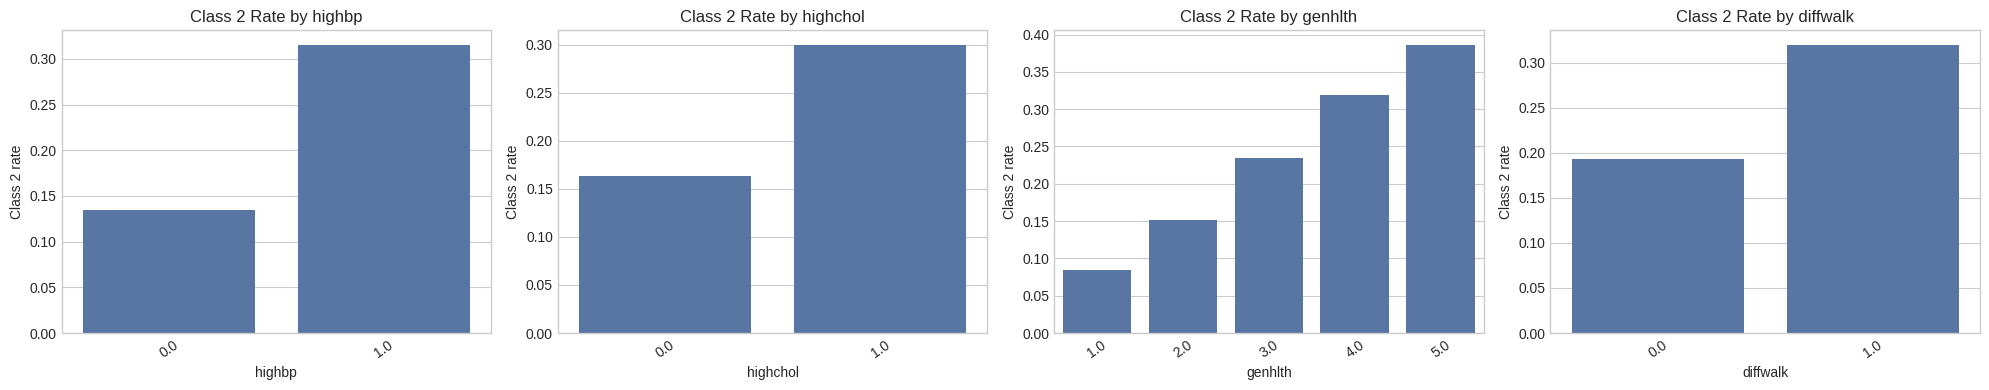

diabetes_012              0          1          2
age       mean     8.073384   9.025706   9.278079
          median   8.000000   9.000000   9.000000
          std      3.183936   2.663614   2.444493
bmi       mean    29.302090  30.849208  32.370615
          median  28.000000  30.000000  31.000000
          std      7.977259   7.101066   7.885860
genhlth   mean     2.834815   3.003672   3.382128
          median   3.000000   3.000000   3.000000
          std      1.100814   1.038950   1.032234
physhlth  mean     7.502675   6.714253   9.185001
          median   2.000000   0.000000   3.000000
          std     10.220923  10.469722  11.498137
highbp    mean     0.475508   0.624283   0.734120
          median   0.000000   1.000000   1.000000
          std      0.499403   0.484363   0.441809
highchol  mean     0.452153   0.615102   0.651292
          median   0.000000   1.000000   1.000000
          std      0.497708   0.486627   0.476570
diffwalk  mean     0.276002   0.292174   0.429840
          median   0.000000   0.000000   0.000000
          std      0.447020   0.454814   0.495062
cholcheck mean     0.928890   0.985770   0.991338
          median   1.000000   1.000000   1.000000
          std      0.257011   0.118451   0.092666

,correlation_with_target
highbp,0.220271
genhlth,0.206972
highchol,0.171134
age,0.169228
bmi,0.161581
diffwalk,0.137521
heartdiseaseorattack,0.125257
cholcheck,0.118742
physhlth,0.063993
stroke,0.060772


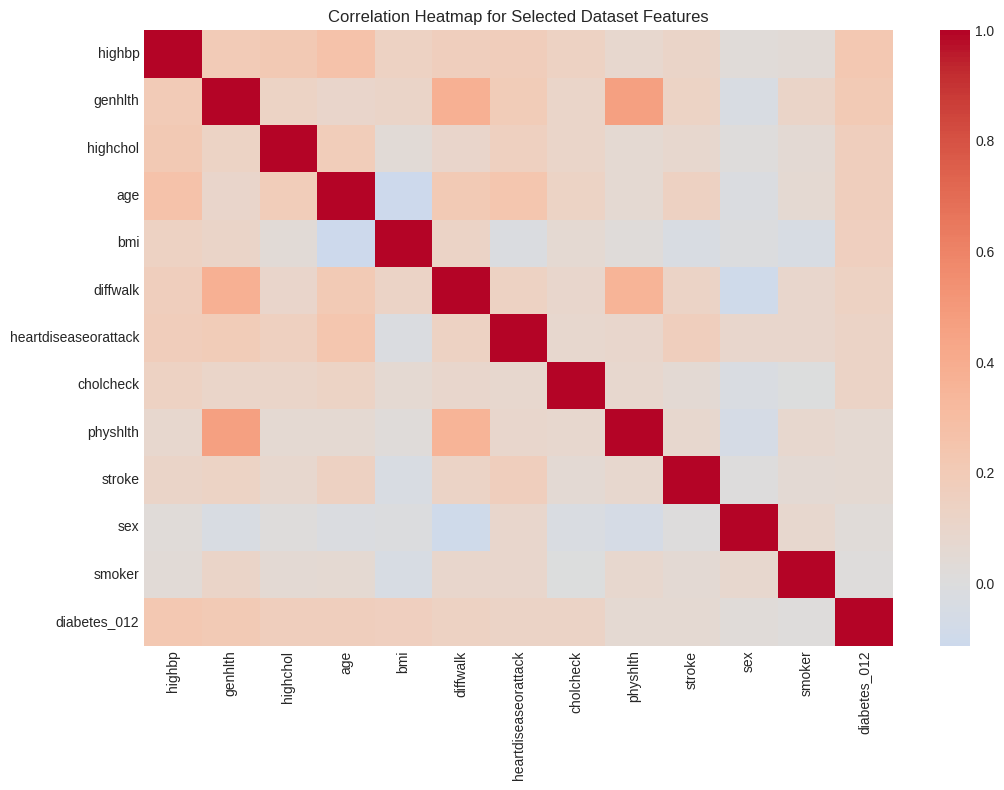

In [3]:
target_table = (
    df["diabetes_012"]
    .value_counts()
    .sort_index()
    .rename_axis("diabetes_012")
    .reset_index(name="count")
)
target_table["share"] = target_table["count"] / len(df)
display(target_table)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="diabetes_012", ax=axes[0])
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Diabetes class")
axes[0].set_ylabel("Count")

age_class_share = pd.crosstab(df["age"], df["diabetes_012"], normalize="index")
age_class_share.plot(marker="o", ax=axes[1])
axes[1].set_title("Class Share by Age")
axes[1].set_xlabel("Age category")
axes[1].set_ylabel("Share")
axes[1].legend(title="Class")

sns.boxplot(data=df.sample(min(10000, len(df)), random_state=42), x="diabetes_012", y="bmi", ax=axes[2])
axes[2].set_title("BMI by Target Class")
axes[2].set_xlabel("Diabetes class")

plt.tight_layout()
plt.show()

rate_features = [feature for feature in [
    "highbp",
    "highchol",
    "genhlth",
    "diffwalk",
    "stroke",
    "heartdiseaseorattack",
] if feature in df.columns]

if rate_features:
    fig, axes = plt.subplots(1, min(4, len(rate_features)), figsize=(20, 4))
    if min(4, len(rate_features)) == 1:
        axes = [axes]
    for axis, feature in zip(axes, rate_features[:4]):
        rate_table = (
            df.assign(is_diabetes_class_2=(df["diabetes_012"] == 2).astype(int))
            .groupby(feature, as_index=False)["is_diabetes_class_2"]
            .mean()
            .sort_values(feature)
        )
        sns.barplot(data=rate_table, x=feature, y="is_diabetes_class_2", ax=axis)
        axis.set_title(f"Class 2 Rate by {feature}")
        axis.set_ylabel("Class 2 rate")
        axis.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()

summary_columns = [column for column in [
    "age",
    "bmi",
    "genhlth",
    "physhlth",
    "highbp",
    "highchol",
    "diffwalk",
    "cholcheck",
] if column in df.columns]

class_summary = df.groupby("diabetes_012")[summary_columns].agg(["mean", "median", "std"]).T
display(class_summary)

numeric_frame = df.apply(pd.to_numeric, errors="coerce")
corr_to_target = (
    numeric_frame
    .corr(numeric_only=True)["diabetes_012"]
    .drop("diabetes_012")
    .sort_values(key=np.abs, ascending=False)
)
display(corr_to_target.rename("correlation_with_target"))

corr_features = corr_to_target.head(12).index.tolist() + ["diabetes_012"]
plt.figure(figsize=(11, 8))
sns.heatmap(numeric_frame[corr_features].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap for Selected Dataset Features")
plt.tight_layout()
plt.show()

## 3. Train/Test Split and Feature Selection Diagnostics

This section uses a normal stratified train/test split and simple feature diagnostics. No feature engineering or advanced feature-set search is used.

Training rows: 95324
Test rows: 23831
Modeling feature count: 12
Modeling features: ['highbp', 'highchol', 'cholcheck', 'bmi', 'smoker', 'stroke', 'heartdiseaseorattack', 'genhlth', 'physhlth', 'diffwalk', 'sex', 'age']


,feature,anova_f,anova_p_value,mutual_information,target_correlation,abs_target_correlation
0,highbp,2452.895056,0.000000e+00,0.025349,0.221120,0.221120
1,genhlth,2174.485095,0.000000e+00,0.022950,0.208233,0.208233
2,bmi,1253.231365,0.000000e+00,0.021720,0.160062,0.160062
3,age,1436.179711,0.000000e+00,0.021705,0.169862,0.169862
4,highchol,1487.792420,0.000000e+00,0.015324,0.172405,0.172405
5,cholcheck,698.573507,6.535859e-302,0.009683,0.118194,0.118194
6,diffwalk,943.164194,0.000000e+00,0.009359,0.137294,0.137294
7,physhlth,223.282900,1.802637e-97,0.008007,0.063061,0.063061
8,heartdiseaseorattack,786.473471,0.000000e+00,0.007528,0.125411,0.125411
9,stroke,204.104964,3.528605e-89,0.001991,0.061963,0.061963


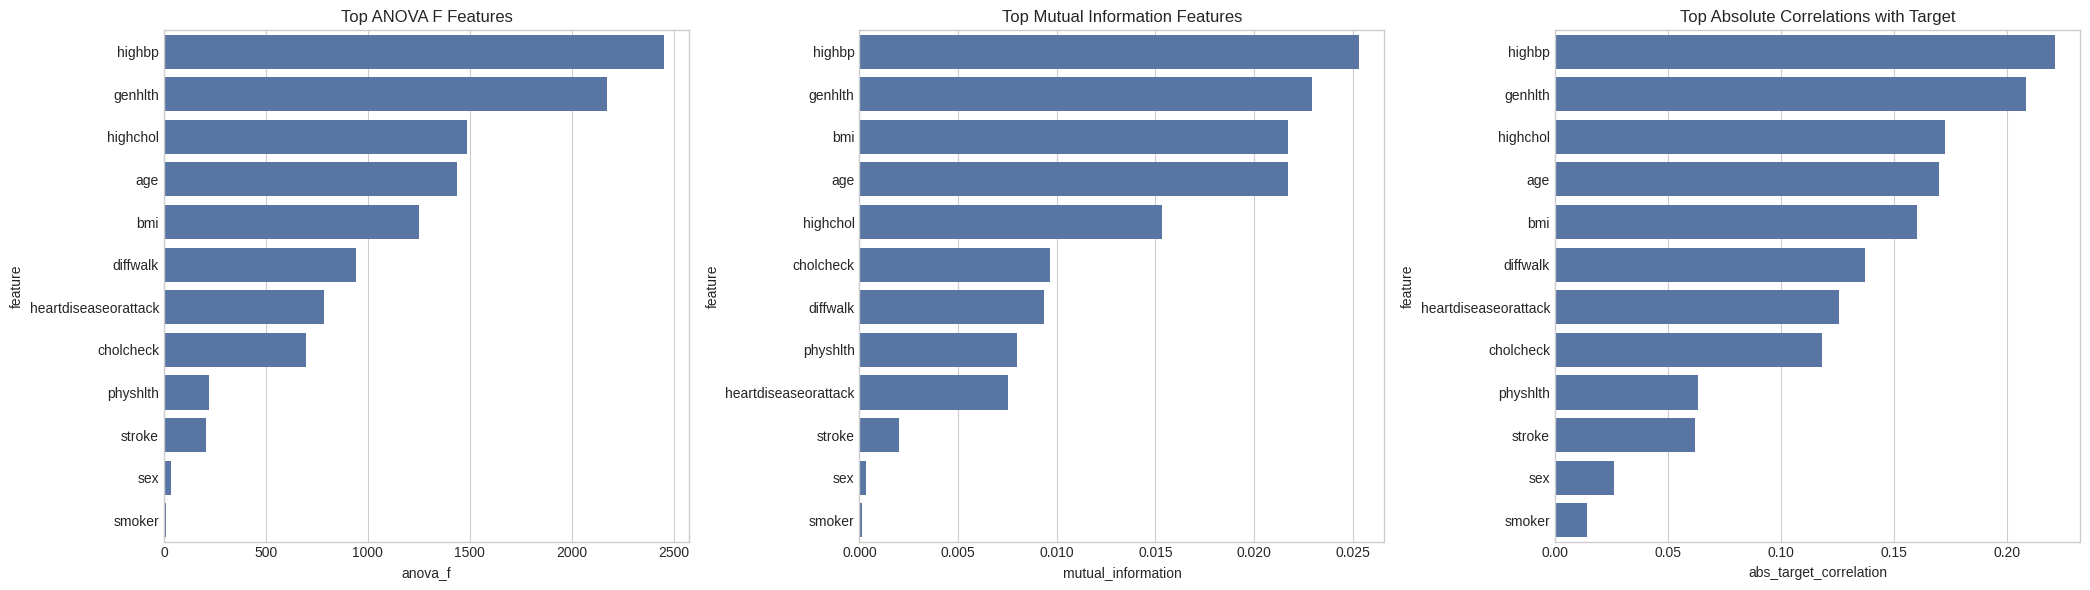

In [4]:
X = df.drop(columns="diabetes_012")
y = df["diabetes_012"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

SELECTED_FEATURES = X_train.columns.tolist()

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Modeling feature count:", len(SELECTED_FEATURES))
print("Modeling features:", SELECTED_FEATURES)

X_train_rank = X_train.apply(pd.to_numeric, errors="coerce")
X_train_rank = X_train_rank.fillna(X_train_rank.median(numeric_only=True))

anova_f_values, anova_p_values = f_classif(X_train_rank, y_train)
mi_values = mutual_info_classif(
    X_train_rank,
    y_train,
    discrete_features=True,
    random_state=42,
)

rank_corr_frame = X_train_rank.copy()
rank_corr_frame["diabetes_012"] = y_train.values
target_correlation = rank_corr_frame.corr(numeric_only=True)["diabetes_012"].drop("diabetes_012")

feature_ranking = pd.DataFrame({
    "feature": SELECTED_FEATURES,
    "anova_f": anova_f_values,
    "anova_p_value": anova_p_values,
    "mutual_information": mi_values,
    "target_correlation": target_correlation.reindex(SELECTED_FEATURES).values,
})
feature_ranking["abs_target_correlation"] = feature_ranking["target_correlation"].abs()
feature_ranking = feature_ranking.sort_values("mutual_information", ascending=False).reset_index(drop=True)

display(feature_ranking)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
sns.barplot(data=feature_ranking.sort_values("anova_f", ascending=False).head(15), x="anova_f", y="feature", ax=axes[0])
axes[0].set_title("Top ANOVA F Features")

sns.barplot(data=feature_ranking.sort_values("mutual_information", ascending=False).head(15), x="mutual_information", y="feature", ax=axes[1])
axes[1].set_title("Top Mutual Information Features")

sns.barplot(data=feature_ranking.sort_values("abs_target_correlation", ascending=False).head(15), x="abs_target_correlation", y="feature", ax=axes[2])
axes[2].set_title("Top Absolute Correlations with Target")

plt.tight_layout()
plt.show()

In [5]:
X_train_model = X_train[SELECTED_FEATURES].apply(pd.to_numeric, errors="coerce")
X_test_model = X_test[SELECTED_FEATURES].apply(pd.to_numeric, errors="coerce")

median_values = X_train_model.median(numeric_only=True)
X_train_model = X_train_model.fillna(median_values)
X_test_model = X_test_model.fillna(median_values)

X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(X_train_model, y_train)
X_train_smote = pd.DataFrame(X_train_smote, columns=SELECTED_FEATURES)
y_train_smote = pd.Series(y_train_smote, name="diabetes_012")

print("Training distribution before SMOTE:")
display(y_train.value_counts().sort_index().rename("count"))

print("Training distribution after SMOTE:")
display(y_train_smote.value_counts().sort_index().rename("count"))

Training distribution before SMOTE:


,count
diabetes_012,
0,69672
1,3486
2,22166


Training distribution after SMOTE:


,count
diabetes_012,
0,69672
1,69672
2,69672


## 4. Extra Trees Model Training

The model is trained directly on the SMOTE-balanced training data using fixed parameters.

In [6]:
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier(
    n_estimators=550,
    max_features="sqrt",
    max_depth=22,
    min_samples_split=8,
    min_samples_leaf=3,
    bootstrap=False,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train_smote, y_train_smote)

print("Extra Trees model trained on SMOTE-balanced multiclass data.")

Extra Trees model trained on SMOTE-balanced multiclass data.


## 5. Final Test Evaluation

The held-out test set is never passed to SMOTE. Metrics are reported for the original three diabetes classes.

,metric,value
0,accuracy,0.694893
1,balanced_accuracy,0.471970
2,macro_precision,0.462257
3,macro_recall,0.471970
4,macro_f1,0.466039
5,weighted_f1,0.698391
6,mcc,0.269353
7,roc_auc_ovr_macro,0.712680
8,pr_auc_macro,0.467164


Classification report:
              precision    recall  f1-score   support

     class_0     0.8148    0.8041    0.8094     17418
     class_1     0.1345    0.1791    0.1536       871
     class_2     0.4375    0.4327    0.4351      5542

    accuracy                         0.6949     23831
   macro avg     0.4623    0.4720    0.4660     23831
weighted avg     0.7022    0.6949    0.6984     23831



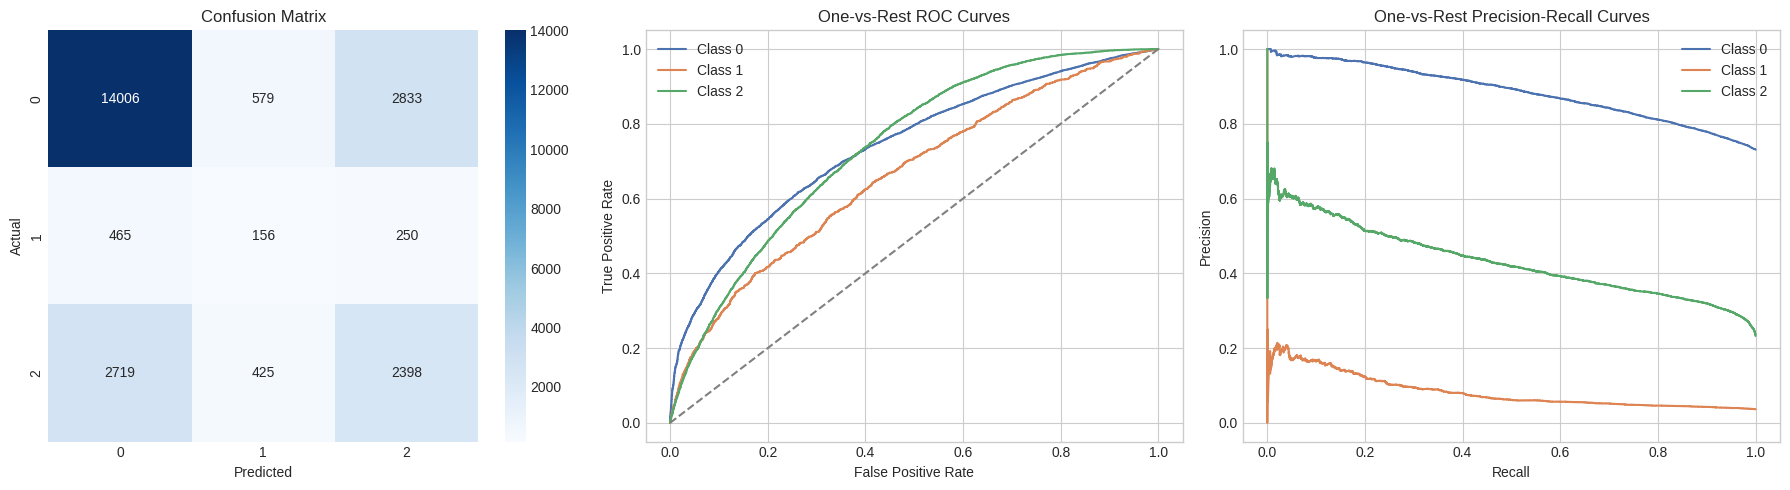

In [7]:
y_pred = model.predict(X_test_model)
y_proba = model.predict_proba(X_test_model)

class_labels = list(model.classes_)
diabetes_class_index = class_labels.index(2)

y_test_binary = label_binarize(y_test, classes=class_labels)

metrics_table = pd.DataFrame({
    "metric": [
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "mcc",
        "roc_auc_ovr_macro",
        "pr_auc_macro",
    ],
    "value": [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="macro", zero_division=0),
        recall_score(y_test, y_pred, average="macro", zero_division=0),
        f1_score(y_test, y_pred, average="macro", zero_division=0),
        f1_score(y_test, y_pred, average="weighted", zero_division=0),
        matthews_corrcoef(y_test, y_pred),
        roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"),
        average_precision_score(y_test_binary, y_proba, average="macro"),
    ],
})

display(metrics_table)

print("Classification report:")
print(classification_report(
    y_test,
    y_pred,
    labels=class_labels,
    target_names=[f"class_{label}" for label in class_labels],
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_test, y_pred, labels=class_labels)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=class_labels, yticklabels=class_labels)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

for class_index, class_value in enumerate(class_labels):
    fpr, tpr, _ = roc_curve((y_test == class_value).astype(int), y_proba[:, class_index])
    axes[1].plot(fpr, tpr, label=f"Class {class_value}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_title("One-vs-Rest ROC Curves")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

for class_index, class_value in enumerate(class_labels):
    precision_vals, recall_vals, _ = precision_recall_curve((y_test == class_value).astype(int), y_proba[:, class_index])
    axes[2].plot(recall_vals, precision_vals, label=f"Class {class_value}")
axes[2].set_title("One-vs-Rest Precision-Recall Curves")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Built-in Importance, SHAP, and LIME

These explanations use the fitted model. Global explanations show important features, and the local LIME example explains one high-risk class-2 prediction.

,feature,importance
0,highbp,0.158296
1,highchol,0.140582
2,genhlth,0.110877
3,physhlth,0.088840
4,diffwalk,0.084282
5,age,0.081160
6,sex,0.072450
7,smoker,0.072082
8,heartdiseaseorattack,0.059197
9,bmi,0.057668


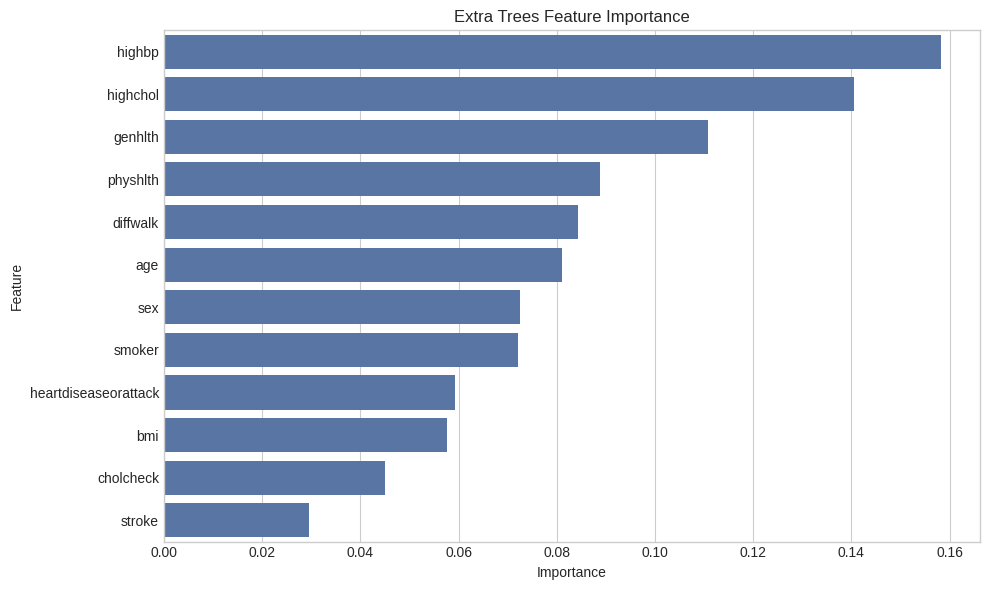

In [ ]:
feature_importance_table = (
    pd.DataFrame({
        "feature": SELECTED_FEATURES,
        "importance": model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_table)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_table.head(15), x="importance", y="feature")
plt.title("Extra Trees Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

X_explain = X_test_model.sample(min(1000, len(X_test_model)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_explain)

if isinstance(shap_values, list):
    shap_matrix = shap_values[diabetes_class_index]
elif hasattr(shap_values, "values"):
    shap_array = np.array(shap_values.values)
    if shap_array.ndim == 3 and shap_array.shape[2] == len(class_labels):
        shap_matrix = shap_array[:, :, diabetes_class_index]
    elif shap_array.ndim == 3 and shap_array.shape[0] == len(class_labels):
        shap_matrix = shap_array[diabetes_class_index]
    else:
        shap_matrix = shap_array
else:
    shap_array = np.array(shap_values)
    if shap_array.ndim == 3 and shap_array.shape[2] == len(class_labels):
        shap_matrix = shap_array[:, :, diabetes_class_index]
    elif shap_array.ndim == 3 and shap_array.shape[0] == len(class_labels):
        shap_matrix = shap_array[diabetes_class_index]
    else:
        shap_matrix = shap_array

shap.summary_plot(
    shap_matrix,
    features=X_explain,
    feature_names=SELECTED_FEATURES,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Global Importance for Class 2")
plt.tight_layout()
plt.show()

lime_training_frame = X_train_model.sample(min(5000, len(X_train_model)), random_state=42)

lime_explainer = LimeTabularExplainer(
    training_data=lime_training_frame.to_numpy(dtype=float),
    feature_names=SELECTED_FEATURES,
    class_names=[f"class_{label}" for label in class_labels],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

class_2_probability = pd.Series(y_proba[:, diabetes_class_index], index=X_test_model.index, name="predicted_class_2_probability")
class_2_test_indices = y_test[y_test == 2].index.intersection(X_test_model.index)

if len(class_2_test_indices) > 0:
    lime_index = class_2_probability.loc[class_2_test_indices].sort_values(ascending=False).index[0]
else:
    lime_index = class_2_probability.sort_values(ascending=False).index[0]

lime_instance = X_test_model.loc[lime_index, SELECTED_FEATURES]

lime_explanation = lime_explainer.explain_instance(
    data_row=lime_instance.to_numpy(dtype=float),
    predict_fn=lambda rows: model.predict_proba(pd.DataFrame(rows, columns=SELECTED_FEATURES)),
    num_features=min(10, len(SELECTED_FEATURES)),
    labels=(diabetes_class_index,),
)

print("LIME explained row index:", lime_index)
print("Actual class:", int(y_test.loc[lime_index]))
print("Predicted class 2 probability:", round(float(class_2_probability.loc[lime_index]), 4))

lime_table = pd.DataFrame(
    lime_explanation.as_list(label=diabetes_class_index),
    columns=["feature_condition", "lime_weight_for_class_2"],
)
display(lime_table)

fig = lime_explanation.as_pyplot_figure(label=diabetes_class_index)
plt.title("LIME Local Explanation for Class 2")
plt.tight_layout()
plt.show()

## 7. Permutation and Drop-Column Importance

Permutation importance tests how prediction quality changes when one feature is shuffled. Drop-column importance retrains simple copies of the model after removing one feature at a time.

In [ ]:
X_perm = X_test_model.sample(min(1500, len(X_test_model)), random_state=42)
y_perm = y_test.loc[X_perm.index]

perm_result = permutation_importance(
    model,
    X_perm,
    y_perm,
    scoring="balanced_accuracy",
    n_repeats=5,
    random_state=42,
    n_jobs=1,
)

permutation_importance_table = (
    pd.DataFrame({
        "feature": SELECTED_FEATURES,
        "permutation_importance_mean": perm_result.importances_mean,
        "permutation_importance_std": perm_result.importances_std,
    })
    .sort_values("permutation_importance_mean", ascending=False)
    .reset_index(drop=True)
)
display(permutation_importance_table.head(25))

plt.figure(figsize=(10, 6))
sns.barplot(data=permutation_importance_table.head(15), x="permutation_importance_mean", y="feature")
plt.title("Permutation Importance")
plt.xlabel("Mean balanced accuracy decrease")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

X_dc_train, X_dc_valid, y_dc_train, y_dc_valid = train_test_split(
    X_train_model,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42,
)

X_dc_train_smote, y_dc_train_smote = SMOTE(random_state=42).fit_resample(X_dc_train, y_dc_train)
X_dc_train_smote = pd.DataFrame(X_dc_train_smote, columns=SELECTED_FEATURES)

base_drop_model = clone(model)
base_drop_model.fit(X_dc_train_smote, y_dc_train_smote)
base_drop_proba = base_drop_model.predict_proba(X_dc_valid)
base_drop_auc = roc_auc_score(y_dc_valid, base_drop_proba, multi_class="ovr", average="macro")

drop_rows = []
for feature in permutation_importance_table.head(8)["feature"].tolist():
    reduced_features = [column for column in SELECTED_FEATURES if column != feature]
    reduced_train = X_dc_train[reduced_features]
    reduced_valid = X_dc_valid[reduced_features]

    reduced_train_smote, reduced_y_smote = SMOTE(random_state=42).fit_resample(reduced_train, y_dc_train)
    reduced_train_smote = pd.DataFrame(reduced_train_smote, columns=reduced_features)

    reduced_model = clone(model)
    reduced_model.fit(reduced_train_smote, reduced_y_smote)
    reduced_proba = reduced_model.predict_proba(reduced_valid)
    reduced_auc = roc_auc_score(y_dc_valid, reduced_proba, multi_class="ovr", average="macro")

    drop_rows.append({
        "dropped_feature": feature,
        "base_auc": base_drop_auc,
        "auc_without_feature": reduced_auc,
        "drop_column_importance": base_drop_auc - reduced_auc,
    })

drop_column_importance_table = (
    pd.DataFrame(drop_rows)
    .sort_values("drop_column_importance", ascending=False)
    .reset_index(drop=True)
)
display(drop_column_importance_table)

plt.figure(figsize=(9, 5))
sns.barplot(data=drop_column_importance_table, x="drop_column_importance", y="dropped_feature")
plt.axvline(0, color="grey", linestyle="--")
plt.title("Drop-Column Importance")
plt.xlabel("Validation ROC AUC decrease after dropping feature")
plt.ylabel("Dropped feature")
plt.tight_layout()
plt.show()

## 8. PDP, ICE, and ALE

PDP shows the average modeled effect of a feature. ICE shows individual-level response curves. ALE estimates local changes inside observed feature intervals.

In [ ]:
def top_numeric_explain_features(max_features=3):
    ordered = []
    for table, feature_column in [
        (permutation_importance_table, "feature"),
        (feature_importance_table, "feature"),
        (feature_ranking, "feature"),
    ]:
        for feature in table[feature_column].tolist():
            if feature in SELECTED_FEATURES and feature not in ordered:
                if pd.api.types.is_numeric_dtype(X_train_model[feature]) and X_train_model[feature].nunique(dropna=True) >= 3:
                    ordered.append(feature)
            if len(ordered) >= max_features:
                return ordered
    return ordered

pdp_features = top_numeric_explain_features(max_features=3)
print("PDP/ALE numeric features:", pdp_features)

X_pdp = X_test_model.sample(min(1000, len(X_test_model)), random_state=42)

if pdp_features:
    PartialDependenceDisplay.from_estimator(
        model,
        X_pdp,
        features=pdp_features,
        kind="average",
        grid_resolution=20,
        response_method="predict_proba",
        target=2,
    )
    plt.suptitle("Partial Dependence Plots for Class 2", y=1.03)
    plt.tight_layout()
    plt.show()

for feature in pdp_features[:2]:
    PartialDependenceDisplay.from_estimator(
        model,
        X_pdp,
        features=[feature],
        kind="both",
        subsample=min(300, len(X_pdp)),
        centered=True,
        grid_resolution=20,
        random_state=42,
        response_method="predict_proba",
        target=2,
    )
    plt.suptitle(f"ICE Plot for {feature} - Class 2", y=1.03)
    plt.tight_layout()
    plt.show()

In [ ]:
def compute_ale_1d(estimator, data, feature, bins=10):
    work = data.copy()
    values = pd.to_numeric(work[feature], errors="coerce").dropna()
    quantiles = np.unique(np.quantile(values, np.linspace(0, 1, bins + 1)))

    if len(quantiles) < 3:
        unique_values = np.sort(values.unique())
        if len(unique_values) < 3:
            return pd.DataFrame(columns=["feature", "bin_center", "ale", "bin_count"])
        quantiles = unique_values

    interval_effects = []
    interval_centers = []
    interval_counts = []

    for index, (lower, upper) in enumerate(zip(quantiles[:-1], quantiles[1:])):
        if lower == upper:
            continue
        if index == len(quantiles) - 2:
            mask = (work[feature] >= lower) & (work[feature] <= upper)
        else:
            mask = (work[feature] >= lower) & (work[feature] < upper)

        if mask.sum() == 0:
            continue

        lower_frame = work.loc[mask].copy()
        upper_frame = work.loc[mask].copy()
        lower_frame[feature] = lower
        upper_frame[feature] = upper

        lower_pred = estimator.predict_proba(lower_frame)[:, diabetes_class_index]
        upper_pred = estimator.predict_proba(upper_frame)[:, diabetes_class_index]

        interval_effects.append(np.mean(upper_pred - lower_pred))
        interval_centers.append((lower + upper) / 2)
        interval_counts.append(int(mask.sum()))

    if not interval_effects:
        return pd.DataFrame(columns=["feature", "bin_center", "ale", "bin_count"])

    ale_values = np.cumsum(interval_effects)
    ale_values = ale_values - np.average(ale_values, weights=interval_counts)

    return pd.DataFrame({
        "feature": feature,
        "bin_center": interval_centers,
        "ale": ale_values,
        "bin_count": interval_counts,
    })

ale_tables = []
for feature in pdp_features:
    feature_ale_table = compute_ale_1d(model, X_pdp, feature, bins=10)
    if not feature_ale_table.empty:
        ale_tables.append(feature_ale_table)

if ale_tables:
    ale_table = pd.concat(ale_tables, ignore_index=True)
    display(ale_table)

    feature_count = ale_table["feature"].nunique()
    fig, axes = plt.subplots(1, feature_count, figsize=(5 * feature_count, 4))
    if feature_count == 1:
        axes = [axes]
    for axis, (feature, feature_table) in zip(axes, ale_table.groupby("feature")):
        sns.lineplot(data=feature_table, x="bin_center", y="ale", marker="o", ax=axis)
        axis.axhline(0, color="grey", linestyle="--", linewidth=1)
        axis.set_title(f"ALE: {feature}")
        axis.set_xlabel(feature)
        axis.set_ylabel("Centered local effect")
    plt.suptitle("Accumulated Local Effects for Class 2", y=1.04)
    plt.tight_layout()
    plt.show()
else:
    print("ALE skipped because no numeric feature had enough unique values.")

## 9. Feature Interaction H-Statistics

The H-statistic estimates how strongly two features interact in the fitted model. This version uses a small prediction-grid approximation so it stays readable in Colab.

In [ ]:
def feature_grid(data, feature, points=8):
    values = pd.to_numeric(data[feature], errors="coerce").dropna()
    if values.nunique() <= points:
        return np.sort(values.unique())
    return np.unique(np.quantile(values, np.linspace(0.05, 0.95, points)))


def mean_prediction_with_updates(estimator, background, updates):
    updated = background.copy()
    for feature, value in updates.items():
        updated[feature] = value
    return estimator.predict_proba(updated)[:, diabetes_class_index].mean()


def friedman_h_statistic_pair(estimator, background, feature_a, feature_b, grid_points=8):
    grid_a = feature_grid(background, feature_a, points=grid_points)
    grid_b = feature_grid(background, feature_b, points=grid_points)

    if len(grid_a) < 2 or len(grid_b) < 2:
        return np.nan

    pd_a = np.array([
        mean_prediction_with_updates(estimator, background, {feature_a: value_a})
        for value_a in grid_a
    ])
    pd_b = np.array([
        mean_prediction_with_updates(estimator, background, {feature_b: value_b})
        for value_b in grid_b
    ])
    pd_ab = np.array([
        [
            mean_prediction_with_updates(estimator, background, {feature_a: value_a, feature_b: value_b})
            for value_b in grid_b
        ]
        for value_a in grid_a
    ])

    pd_a_centered = pd_a - pd_a.mean()
    pd_b_centered = pd_b - pd_b.mean()
    pd_ab_centered = pd_ab - pd_ab.mean()

    interaction_component = pd_ab_centered - pd_a_centered[:, None] - pd_b_centered[None, :]
    numerator = np.sum(interaction_component ** 2)
    denominator = np.sum(pd_ab_centered ** 2)

    if denominator == 0:
        return np.nan

    return float(np.sqrt(np.clip(numerator / denominator, 0, 1)))

hstat_features = top_numeric_explain_features(max_features=4)
X_hstat = X_test_model.sample(min(500, len(X_test_model)), random_state=42)

h_rows = []
for feature_a, feature_b in combinations(hstat_features, 2):
    h_rows.append({
        "feature_a": feature_a,
        "feature_b": feature_b,
        "h_statistic": friedman_h_statistic_pair(model, X_hstat, feature_a, feature_b, grid_points=8),
    })

h_statistics = pd.DataFrame(h_rows).sort_values("h_statistic", ascending=False).reset_index(drop=True)
display(h_statistics)

if not h_statistics.empty:
    plt.figure(figsize=(10, 6))
    plot_table = h_statistics.copy()
    plot_table["pair"] = plot_table["feature_a"] + " x " + plot_table["feature_b"]
    sns.barplot(data=plot_table, x="h_statistic", y="pair")
    plt.title("Feature Interaction H-Statistics for Class 2")
    plt.xlabel("Approximate H-statistic")
    plt.ylabel("Feature pair")
    plt.tight_layout()
    plt.show()